https://www.kaggle.com/datasets/fratzcan/usa-house-prices?resource=download

In [311]:
import pandas as pd

df = pd.read_csv('USA Housing Dataset.csv')
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-09 00:00:00,376000.0,3.0,2.00,1340,1384,3.0,0,0,3,1340,0,2008,0,9245-9249 Fremont Ave N,Seattle,WA 98103,USA
1,2014-05-09 00:00:00,800000.0,4.0,3.25,3540,159430,2.0,0,0,3,3540,0,2007,0,33001 NE 24th St,Carnation,WA 98014,USA
2,2014-05-09 00:00:00,2238888.0,5.0,6.50,7270,130017,2.0,0,0,3,6420,850,2010,0,7070 270th Pl SE,Issaquah,WA 98029,USA
3,2014-05-09 00:00:00,324000.0,3.0,2.25,998,904,2.0,0,0,3,798,200,2007,0,820 NW 95th St,Seattle,WA 98117,USA
4,2014-05-10 00:00:00,549900.0,5.0,2.75,3060,7015,1.0,0,0,5,1600,1460,1979,0,10834 31st Ave SW,Seattle,WA 98146,USA


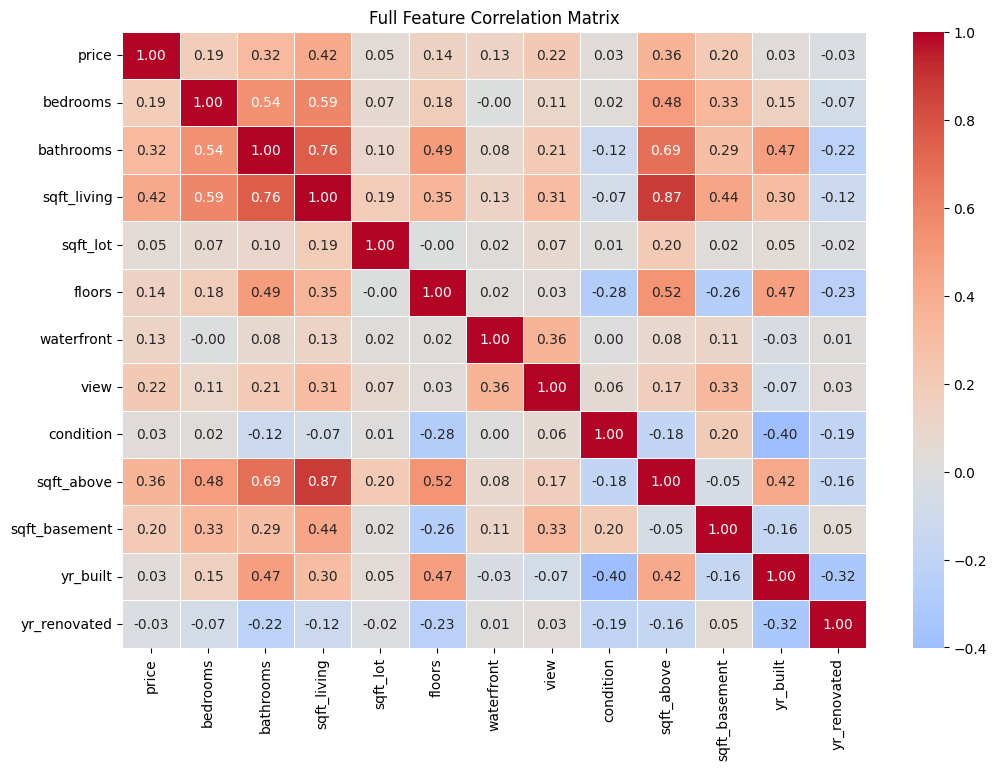

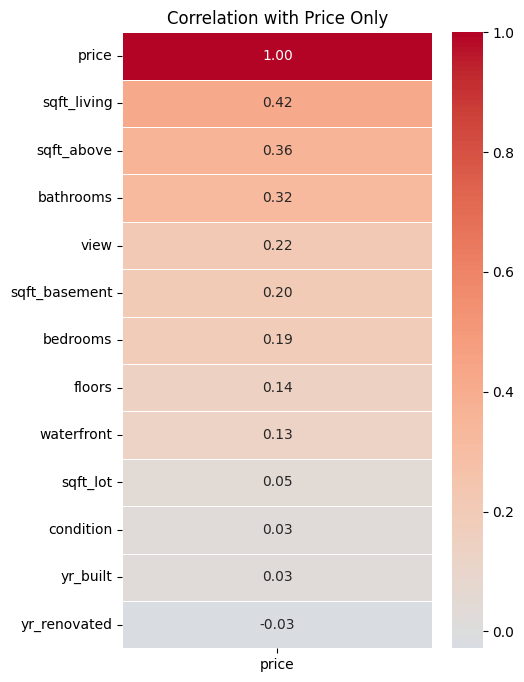

In [312]:
# Correlation heatmaps
import matplotlib.pyplot as plt
import seaborn as sns

full_corr = df.corr(numeric_only=True)
price_corr = full_corr[['price']].sort_values(by='price', ascending=False)

# Full correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(full_corr, annot=True, fmt=".2f", cmap='coolwarm', center=0, linewidths=0.5)
plt.title("Full Feature Correlation Matrix")
plt.show()

# Correlation with price only
plt.figure(figsize=(5, 8)) 
sns.heatmap(price_corr, annot=True, fmt=".2f", cmap='coolwarm', center=0, linewidths=0.5)
plt.title("Correlation with Price Only")
plt.show()

Notes about the features: 
- sqft_living is equal to = sqft_above + sqft_basement. Therefore we can just drop the above and basement columns
- Statezip and street likely dont have as much influence as city, so I'll drop them    
- All dates and countries are same/similar so drop them
- It'll make more sense for models if yr_built is converted to an age
- One-hot encode the City column that way it isnt a string but a distinct location

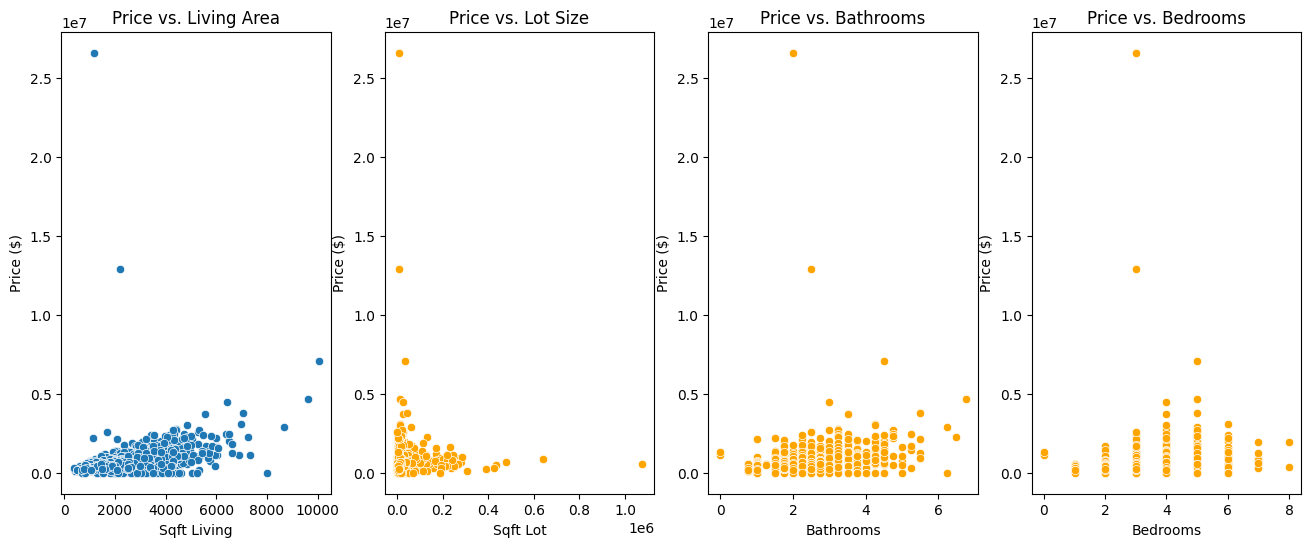

In [313]:
# Scatter plots for top correlated features
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 4, figsize=(16, 6))

# sft_living
sns.scatterplot(data=df, x='sqft_living', y='price', ax=axes[0])
axes[0].set_title('Price vs. Living Area')
axes[0].set_xlabel('Sqft Living')
axes[0].set_ylabel('Price ($)')

# sqft_lot
sns.scatterplot(data=df, x='sqft_lot', y='price', ax=axes[1], color='orange')
axes[1].set_title('Price vs. Lot Size')
axes[1].set_xlabel('Sqft Lot')
axes[1].set_ylabel('Price ($)')

# bathrooms
sns.scatterplot(data=df, x='bathrooms', y='price', ax=axes[2], color='orange')
axes[2].set_title('Price vs. Bathrooms')
axes[2].set_xlabel('Bathrooms')
axes[2].set_ylabel('Price ($)')

# bedrooms
sns.scatterplot(data=df, x='bedrooms', y='price', ax=axes[3], color='orange')
axes[3].set_title('Price vs. Bedrooms')
axes[3].set_xlabel('Bedrooms')
axes[3].set_ylabel('Price ($)')

plt.show()

In [314]:

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Remove extreme outliers based on price (keep 1st to 99th percentile)
lower_limit = df['price'].quantile(0.01)
upper_limit = df['price'].quantile(0.99)

# Added .copy() to avoid SettingWithCopy warnings later
df_clean = df[(df['price'] >= lower_limit) & (df['price'] <= upper_limit) & (df['price'] > 0)].copy()

# 2. FEATURE ENGINEERING (Before dropping columns)
# We need 'yr_renovated' and 'yr_built' to create these new features
df_clean['was_renovated'] = (df_clean['yr_renovated'] > 0).astype(int)
df_clean['age'] = df_clean['yr_built'].max() - df_clean['yr_built']

features = ['city', 'bedrooms', 'bathrooms', 'sqft_living', 
             'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 
             'was_renovated', 'age']

# 3. SELECTING RELEVANT COLUMNS
# Define what we want to keep (including the ones we will encode)

df_final = df_clean[features + ['price']].copy()

# One hot encode city 
df_final = pd.get_dummies(df_final, columns=['city'], drop_first=True)


X = df_final.drop('price', axis=1)
y = df_final['price']

# ln(y)

ln_y = np.log1p(y)

# Train test split (80/20) with random_state=42 for reproducibility
X_train, X_test, y_train, y_test = train_test_split(X, ln_y, test_size=0.2, random_state=42)

# Standard scale X

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X.head()

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,was_renovated,age,...,city_SeaTac,city_Seattle,city_Shoreline,city_Skykomish,city_Snoqualmie,city_Snoqualmie Pass,city_Tukwila,city_Vashon,city_Woodinville,city_Yarrow Point
0,3.0,2.00,1340,1384,3.0,0,0,3,0,6,...,False,True,False,False,False,False,False,False,False,False
1,4.0,3.25,3540,159430,2.0,0,0,3,0,7,...,False,False,False,False,False,False,False,False,False,False
3,3.0,2.25,998,904,2.0,0,0,3,0,7,...,False,True,False,False,False,False,False,False,False,False
4,5.0,2.75,3060,7015,1.0,0,0,5,0,35,...,False,True,False,False,False,False,False,False,False,False
5,3.0,2.50,2130,6969,2.0,0,0,3,0,11,...,False,False,False,False,False,False,False,False,False,False


In [315]:
ln_y.describe()

count    4049.000000
mean       13.045912
std         0.516542
min         8.962007
25%        12.691584
50%        13.038984
75%        13.389334
max        14.511155
Name: price, dtype: float64

In [316]:
# Models table and model evaluation functions

from sklearn.model_selection import cross_val_score
from sklearn.metrics import r2_score, mean_absolute_error

models = {}

def evaluate_model(fitted_model):
    ln_preds = fitted_model.predict(X_test)

    print(f"R^2: {r2_score(y_test, ln_preds):.4f}")
    print(f"MAE: ${mean_absolute_error(np.expm1(y_test), np.expm1(ln_preds)):,.2f}")

def cross_validate_model(fitted_model):  
    cv_scores = cross_val_score(fitted_model, X_train, y_train, cv=5, scoring='r2')
    
    print("\nCross-Validation Report")
    print(f"Individual Fold R^2: {cv_scores}")
    print(f"Mean R^2: {cv_scores.mean():.4f}")
    print(f"Standard Deviation: {cv_scores.std():.4f}")

In [317]:
# Linear Regression
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

evaluate_model(lr_model)
cross_validate_model(lr_model)

R^2: 0.7150
MAE: $104,870.51

Cross-Validation Report
Individual Fold R^2: [0.70322181 0.72144659 0.66400906 0.72909348 0.70545956]
Mean R^2: 0.7046
Standard Deviation: 0.0225


In [318]:
# Random Forest Regressor

from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

evaluate_model(rf_model)
cross_validate_model(rf_model)

R^2: 0.7167
MAE: $106,315.85

Cross-Validation Report
Individual Fold R^2: [0.69415295 0.71650547 0.65934456 0.70778884 0.70285208]
Mean R^2: 0.6961
Standard Deviation: 0.0198


In [319]:
# XGBoost Regressor

import xgboost as xgb

# Model definition
xgb_model = xgb.XGBRegressor(
    n_estimators=2000, 
    learning_rate=0.05, 
    max_depth=6, 
    subsample=0.8,
    colsample_bytree=0.8,
    early_stopping_rounds=50,
    n_jobs=-1,
    random_state=42
)

# Fit 
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

evaluate_model(xgb_model)

R^2: 0.7422
MAE: $98,668.47


In [320]:
# Feedforward Neural Network (FFN)

import tensorflow as tf
from tensorflow.keras import layers 

# Model definition
ffn_model = tf.keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(X_train.shape[1],), kernel_regularizer=tf.keras.regularizers.l2(0.01)),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
        layers.BatchNormalization(),
    layers.Dense(32, activation='relu'),
    layers.Dense(1) 
])

# Compile
ffn_model.compile(optimizer=tf.keras.optimizers.Adam(0.005), loss="mse")

# Fit
ffn_model.fit(
    X_train, y_train, 
    epochs=150, 
    batch_size=32,
    validation_split=0.1, 
    verbose=True,   
    callbacks=[tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)]
)

Epoch 1/150


C:\Users\DEVal\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 29.1108 - val_loss: 10.1162
Epoch 2/150
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.1230 - val_loss: 2.8429
Epoch 3/150
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.6135 - val_loss: 1.1287
Epoch 4/150
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.2136 - val_loss: 0.9115
Epoch 5/150
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9958 - val_loss: 0.7020
Epoch 6/150
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9321 - val_loss: 0.6092
Epoch 7/150
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.8163 - val_loss: 0.5790
Epoch 8/150
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.8120 - val_loss: 0.7090
Epoch 9/150
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7948 - val_loss: 0.5943
Epoch 10/150
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6881 - val_loss: 0.6396
Epoch 11/150
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7599 - val_loss: 0.5640
Epoch 12/150
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6883 - val_

In [321]:
evaluate_model(ffn_model)

26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
R^2: 0.6986
MAE: $105,751.06
